<a href="https://colab.research.google.com/github/anitapathak/ML_lab_And_Assignment/blob/main/ML_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# =====================================================================
# CORE DATA PREPROCESSING BLOCK (FIXED VERSION)
# =====================================================================
import os
import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

print("Downloading dataset...")
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Downsample to 10k rows for faster processing
if len(df) > 10000:
    df = df.sample(n=10000, random_state=42, weights=df['is_canceled'].map({0: 0.5, 1: 0.5}))

# Drop duplicates
df = df.drop_duplicates()

# Clean missing values cleanly without triggering chained assignment warnings
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna('Unknown')
        else:
            df[col] = df[col].fillna(df[col].median())

X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

# Label encode categorical strings
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# Train-Test Split (80/20) -> Fixed parameter name to 'test_size'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete! Training arrays are ready without warnings.")

Using Colab cache for faster access to the 'hotel-booking-demand' dataset.
Data preparation complete! Training arrays are ready without warnings.


--- Training Support Vector Machine ---
SVM Accuracy  : 0.9842
SVM Precision : 1.0000
SVM Recall    : 0.9519
SVM F1-Score  : 0.9754


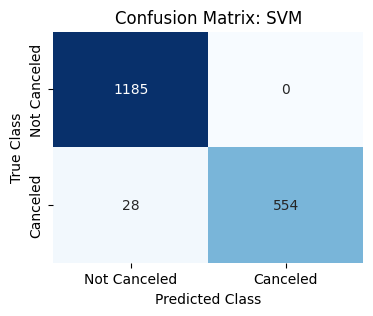

In [3]:
# =====================================================================
# INDIVIDUAL MODEL: SUPPORT VECTOR MACHINE
# =====================================================================
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- Training Support Vector Machine ---")
svm_model = SVC(random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test_scaled)

# Metrics
print(f"SVM Accuracy  : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"SVM Precision : {precision_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"SVM Recall    : {recall_score(y_test, y_pred_svm, zero_division=0):.4f}")
print(f"SVM F1-Score  : {f1_score(y_test, y_pred_svm, zero_division=0):.4f}")

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Confusion Matrix: SVM')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

--- Training Decision Tree ---
Decision Tree Accuracy  : 1.0000
Decision Tree Precision : 1.0000
Decision Tree Recall    : 1.0000
Decision Tree F1-Score  : 1.0000


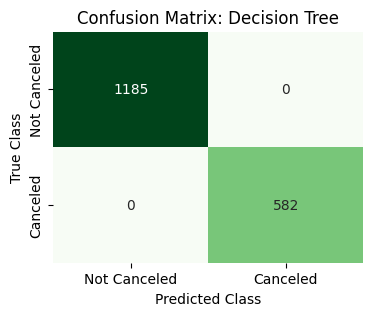

In [4]:
# =====================================================================
# INDIVIDUAL MODEL: DECISION TREE
# =====================================================================
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- Training Decision Tree ---")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)

# Metrics
print(f"Decision Tree Accuracy  : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Decision Tree Precision : {precision_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"Decision Tree Recall    : {recall_score(y_test, y_pred_dt, zero_division=0):.4f}")
print(f"Decision Tree F1-Score  : {f1_score(y_test, y_pred_dt, zero_division=0):.4f}")

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Confusion Matrix: Decision Tree')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

--- Training Baseline kNN ---
Baseline kNN Accuracy : 0.9643
Baseline kNN F1-Score : 0.9432

--- Performing Hyperparameter Tuning for kNN ---
Best Configuration Found: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}

Tuned kNN Accuracy  : 0.9711
Tuned kNN Precision : 0.9981
Tuned kNN Recall    : 0.9141
Tuned kNN F1-Score  : 0.9543


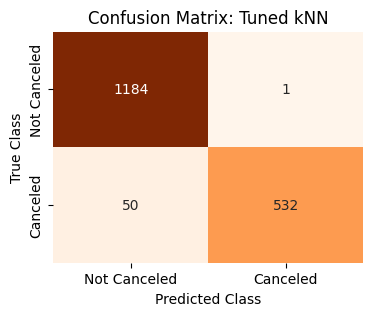

In [5]:
# =====================================================================
# INDIVIDUAL MODEL: k-NEAREST NEIGHBORS (WITH TUNING)
# =====================================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("--- Training Baseline kNN ---")
knn_baseline = KNeighborsClassifier()
knn_baseline.fit(X_train_scaled, y_train)
y_pred_knn = knn_baseline.predict(X_test_scaled)

print(f"Baseline kNN Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Baseline kNN F1-Score : {f1_score(y_test, y_pred_knn, zero_division=0):.4f}\n")

print("--- Performing Hyperparameter Tuning for kNN ---")
param_grid = {
    'n_neighbors': [5, 9, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best Configuration Found: {grid_search.best_params_}\n")

# Evaluate Best Model
knn_tuned = grid_search.best_estimator_
y_pred_tuned = knn_tuned.predict(X_test_scaled)

print(f"Tuned kNN Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned kNN Precision : {precision_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print(f"Tuned kNN Recall    : {recall_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print(f"Tuned kNN F1-Score  : {f1_score(y_test, y_pred_tuned, zero_division=0):.4f}")

# Confusion Matrix for Tuned kNN
plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test, y_pred_tuned), annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Not Canceled', 'Canceled'], yticklabels=['Not Canceled', 'Canceled'])
plt.title('Confusion Matrix: Tuned kNN')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()